# Equity Derivatives in Practice — Practice Set 3
## Delta-hedging P&L and realized volatility (`EquityDerivsPractice_PSet3.xlsx`)

**The experiment.** At $t=0$ we **sell 100,000 European call options** and receive the Black-Scholes
premium computed with an **implied volatility of 30%**. We then run a **self-financing delta-hedging
strategy** that tries to manufacture the option payoff: at each of the 50 hedging dates we hold
$\Delta_t = N(d_1)$ shares per option and park the rest in the cash account at the risk-free rate.

At expiration we compare what the hedge is worth with what we owe:

$$
\text{Total hedging P\&L} \;=\; \underbrace{V_{T}}_{\text{final value of the self-financing portfolio}}
\;-\; \underbrace{100{,}000\times\max(S_T-K,\,0)}_{\text{option payoff we must pay}}
$$

This is exactly cell **B11** of the `DemoSheet` worksheet.

**The task.** The `StockPricePaths` worksheet holds four *new* price paths. For each path we must report

| Question | Path | Quantity | Format |
|---|---|---|---|
| 1 | #1 | annualized realized volatility of log-returns | % , 2 dp |
| 2 | #1 | total realized hedging P&L | nearest integer |
| 3 | #2 | annualized realized volatility of log-returns | % , 2 dp |
| 4 | #2 | total realized hedging P&L | nearest integer |
| 5 | #3 | annualized realized volatility of log-returns | % , 2 dp |
| 6 | #3 | total realized hedging P&L | nearest integer |
| 7 | #4 | annualized realized volatility of log-returns | % , 2 dp |
| 8 | #4 | total realized hedging P&L | nearest integer |

The final comparison is the point of the exercise: **realized volatility vs. the 30% implied volatility
used to price and hedge the options.**

## 1. The mathematics, one line at a time

### 1.1 Parameters

| Symbol | Meaning | Cell | Value |
|---|---|---|---|
| $S_0$ | initial stock price | `DemoSheet!B2` | 50 |
| $T$ | time to expiration, in years | `DemoSheet!B3` | 0.25 |
| $\sigma_{\text{imp}}$ | implied volatility used to price **and** to hedge | `DemoSheet!B4` | 30% |
| $r$ | risk-free rate (continuously compounded) | `DemoSheet!B5` | 2% |
| $K$ | strike | `DemoSheet!B6` | 50 |
| $M$ | number of options sold | `DemoSheet!B7` | 100,000 |
| $n$ | number of hedging periods | `DemoSheet!B8` | 50 |
| $\Delta t$ | length of one hedging period | $T/n$ | $0.25/50 = 0.005$ yr |

Note $\Delta t$ is the bridge between "per period" and "per year": one period is $0.005$ years, so there
are $1/\Delta t = 200$ periods in a year.

### 1.2 Black-Scholes call price and delta

With time to maturity $\tau = T - t$:

$$
d_1=\frac{\ln(S_t/K)+\left(r+\tfrac12\sigma_{\text{imp}}^2\right)\tau}{\sigma_{\text{imp}}\sqrt{\tau}},
\qquad
d_2=d_1-\sigma_{\text{imp}}\sqrt{\tau}
$$

$$
C(S_t,\tau)=S_t N(d_1)-Ke^{-r\tau}N(d_2),
\qquad
\Delta_t=\frac{\partial C}{\partial S}=N(d_1)
$$

The premium received at $t=0$ is $V_0 = M\cdot C(S_0,T)$ — this is `DemoSheet!B10` $=310{,}815.12$.

### 1.3 The self-financing hedge (the recursion in columns F, H, I of `DemoSheet`)

At each hedging date $t=0,1,\dots,n-1$ we split the portfolio value $V_t$ into stock and cash:

$$
x_t = M\,N(d_1(S_t,\tau_t)) \quad\text{shares},
\qquad
c_t = V_t - x_t S_t \quad\text{dollars in the cash account}
$$

No money is added or withdrawn — that is what **self-financing** means. One period later the portfolio
is worth whatever those two holdings became:

$$
\boxed{\;V_{t+1}=x_t\,S_{t+1}+c_t\,e^{r\Delta t}\;}
$$

Iterate to $t=n$ and compare with the payoff:

$$
\text{P\&L}=V_n-M\max(S_n-K,0)
$$

$c_t$ is large and **negative** (we borrow to buy the hedge), so the cash leg costs interest every period.

### 1.4 Annualized realized volatility

From the $n=50$ prices after $t=0$ we get $n$ log-returns:

$$
u_i=\ln\!\left(\frac{S_i}{S_{i-1}}\right),\qquad i=1,\dots,50
$$

The **sample** standard deviation (Excel's `STDEV`, i.e. divide by $n-1$) is a *per-period* number;
multiply by $\sqrt{1/\Delta t}$ to annualize:

$$
\boxed{\;\hat\sigma_{\text{ann}}
=\sqrt{\frac{1}{n-1}\sum_{i=1}^{n}\left(u_i-\bar u\right)^2}\;\times\;\sqrt{\frac{1}{\Delta t}}\;}
\qquad\text{(here }\sqrt{200}\approx14.142\text{)}
$$

The `DemoSheet` reports this in `N2` for the demo path; reproducing that cell exactly is how we confirm
the convention is *sample* (not population) standard deviation. Column `M2` is the analogous annualized
mean, $\bar u/\Delta t$.

In [7]:
# ---- Imports and plot style ------------------------------------------------
from math import exp, log, sqrt
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import openpyxl
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import norm

# Categorical hues assigned in a fixed order (never cycled), recessive grid/axes.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = SERIES
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#d9d8d4"

plt.rcParams.update({
    "figure.figsize": (9.5, 5.0),
    "figure.dpi": 110,
    "axes.prop_cycle": plt.cycler(color=SERIES),
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK_2,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlecolor": INK,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": GRID,
    "grid.linewidth": 0.6,
    "lines.linewidth": 2.0,
    "legend.frameon": False,
    "text.color": INK,
    "xtick.color": INK_2,
    "ytick.color": INK_2,
    "font.size": 10,
})


def find_workbook(*names):
    """Locate the spreadsheet whether the notebook is run from its own folder or the repo root.

    Several candidate names are accepted: the original course download, or the solutions
    workbook (which carries the same two original worksheets plus the answer sheets).
    """
    here = Path.cwd()
    for base in (here, *here.parents):
        for name in names:
            hit = list(base.glob(f"**/{name}"))
            if hit:
                return hit[0]
    raise FileNotFoundError(names)


XLSX = find_workbook("EquityDerivsPractice_PSet3.xlsx",
                     "EquityDerivsPractice_PSet3_solutions.xlsx")
print(XLSX)

/Users/pathorn.kit/financial-student-lecture/notebook/test/Equity_Derivatives _Practice_Part_I/EquityDerivsPractice_PSet3_solutions.xlsx


In [8]:
# ---- Read the workbook: parameters, the demo path, the four new paths ------
wb = openpyxl.load_workbook(XLSX, data_only=True)
demo, spaths = wb["DemoSheet"], wb["StockPricePaths"]

S0    = demo["B2"].value          # initial stock price
T     = demo["B3"].value          # expiration in years
SIGMA = demo["B4"].value          # IMPLIED vol: used to price and to hedge
R     = demo["B5"].value          # risk-free rate
K     = demo["B6"].value          # strike
M_OPT = int(demo["B7"].value)     # number of options SOLD
N_PER = int(demo["B8"].value)     # number of hedging periods
DT    = T / N_PER                 # length of one hedging period, in years

params = pd.DataFrame(
    {"value": [S0, T, SIGMA, R, K, M_OPT, N_PER, DT, 1 / DT]},
    index=["S0", "T (years)", "implied vol", "risk-free r", "strike K",
           "# options sold", "# hedging periods", "dt = T/n", "periods per year"],
)

# Demo path (column E) and the four new paths (StockPricePaths columns B..E).
demo_path = np.array([demo.cell(row=2 + i, column=5).value for i in range(N_PER + 1)], dtype=float)
paths = {
    f"Path {j}": np.array([spaths.cell(row=2 + i, column=1 + j).value for i in range(N_PER + 1)], dtype=float)
    for j in range(1, 5)
}
paths["Path 4"][0] = S0          # StockPricePaths!E2 is the formula "=B2"

display(params.style.format({"value": "{:,.6g}"}))
print("prices per path:", {k: len(v) for k, v in paths.items()})
print("S_T by path    :", {k: round(v[-1], 4) for k, v in paths.items()})

,value
S0,50
T (years),0.25
implied vol,0.3
risk-free r,0.02
strike K,50
# options sold,"100,000"
# hedging periods,50
dt = T/n,0.005
periods per year,200


prices per path: {'Path 1': 51, 'Path 2': 51, 'Path 3': 51, 'Path 4': 51}
S_T by path    : {'Path 1': np.float64(48.209), 'Path 2': np.float64(54.5557), 'Path 3': np.float64(64.0369), 'Path 4': np.float64(42.9991)}


## 2. The pricing / hedging engine

Three small functions, each a direct transcription of the formulas in section 1:

* `bs_call` → $C(S,\tau)$ and $\Delta=N(d_1)$,
* `realized_vol` → $\hat\sigma_{\text{ann}}$ with Excel's `STDEV` convention (`ddof=1`),
* `delta_hedge` → the self-financing recursion $V_{t+1}=x_tS_{t+1}+c_te^{r\Delta t}$, returning the full
  audit table so every intermediate column can be compared against Excel.

In [9]:
# ---- Black-Scholes, realized volatility, and the self-financing hedge ------
def bs_call(S, K, r, sigma, tau):
    """Black-Scholes call price and delta N(d1). tau = time to maturity in years."""
    if tau <= 0:
        return max(S - K, 0.0), float(S > K)
    d1 = (log(S / K) + (r + 0.5 * sigma ** 2) * tau) / (sigma * sqrt(tau))
    d2 = d1 - sigma * sqrt(tau)
    return S * norm.cdf(d1) - K * exp(-r * tau) * norm.cdf(d2), norm.cdf(d1)


def realized_vol(S, dt):
    """Annualized realized volatility of log-returns, Excel STDEV convention (ddof=1)."""
    u = np.diff(np.log(S))
    return u.std(ddof=1) / sqrt(dt), u.mean() / dt, u


def delta_hedge(S, K=K, r=R, sigma=SIGMA, T=T, n_options=M_OPT, n_periods=N_PER):
    """Sell `n_options` calls, delta-hedge with a self-financing portfolio, return the audit table.

    V_0  = n_options * C(S_0, T)                      (premium received)
    x_t  = n_options * N(d1)                          (shares held over [t, t+1])
    c_t  = V_t - x_t * S_t                            (cash, usually negative)
    V_t+1= x_t * S_t+1 + c_t * exp(r*dt)              (self-financing: no cash in or out)
    """
    dt = T / n_periods
    rows = []
    V = bs_call(S[0], K, r, sigma, T)[0] * n_options
    for t in range(n_periods):
        tau = T - t * dt
        price, delta = bs_call(S[t], K, r, sigma, tau)
        d1 = (log(S[t] / K) + (r + 0.5 * sigma ** 2) * tau) / (sigma * sqrt(tau))
        x = delta * n_options                 # shares held
        c = V - x * S[t]                      # cash account
        rows.append({"t": t, "S_t": S[t], "tau": tau, "d1": d1, "delta = N(d1)": delta,
                     "shares x_t": x, "portfolio V_t": V, "cash c_t": c,
                     "BS option liability": price * n_options})
        V = x * S[t + 1] + c * exp(r * dt)    # <- the self-financing recursion
    payoff = max(S[-1] - K, 0.0) * n_options
    rows.append({"t": n_periods, "S_t": S[-1], "tau": 0.0, "d1": np.nan, "delta = N(d1)": np.nan,
                 "shares x_t": np.nan, "portfolio V_t": V, "cash c_t": np.nan,
                 "BS option liability": payoff})
    return pd.DataFrame(rows), V, payoff, V - payoff

## 3. Validation: reproduce `DemoSheet` before trusting anything

The exercise explicitly says the `DemoSheet` results are there so you can debug. Rather than eyeballing
one cell, we rebuild **every** column of the demo worksheet and take the worst absolute difference:

* `B10` total Black-Scholes premium,
* column `G` ($d_1$), `H` (# stocks held), `I` (cash account), `F` (self-financing portfolio value),
* `N2` annualized realized volatility (this is what pins down `STDEV` vs `STDEVP`),
* `B11` total hedging P&L.

If these all agree to ~1e-8, the engine *is* the spreadsheet.

In [10]:
# ---- Rebuild DemoSheet column by column and diff against the workbook -----
audit_demo, V_T_demo, payoff_demo, pnl_demo = delta_hedge(demo_path)

xl = lambda col, n: np.array([demo.cell(row=2 + i, column=col).value for i in range(n)], dtype=float)
sig_demo, mu_demo, u_demo = realized_vol(demo_path, DT)

checks = pd.DataFrame([
    ("B10  total BS premium", bs_call(S0, K, R, SIGMA, T)[0] * M_OPT, demo["B10"].value),
    ("G     d1 column (max abs diff)", np.abs(audit_demo["d1"][:N_PER] - xl(7, N_PER)).max(), 0.0),
    ("H     # stocks held (max abs diff)", np.abs(audit_demo["shares x_t"][:N_PER] - xl(8, N_PER)).max(), 0.0),
    ("I     cash account (max abs diff)", np.abs(audit_demo["cash c_t"][:N_PER] - xl(9, N_PER)).max(), 0.0),
    ("F     S.F. portfolio (max abs diff)", np.abs(audit_demo["portfolio V_t"] - xl(6, N_PER + 1)).max(), 0.0),
    ("L     log-returns (max abs diff)",
     np.abs(u_demo - np.array([demo.cell(row=3 + i, column=12).value for i in range(N_PER)])).max(), 0.0),
    ("M2   mean log-return, annualized", mu_demo, demo["M2"].value),
    ("N2   realized vol, annualized (STDEV)", sig_demo, demo["N2"].value),
    ("B11  total hedging P&L", pnl_demo, demo["B11"].value),
], columns=["quantity", "python", "workbook"])
checks["difference"] = checks["python"] - checks["workbook"]

# Population std would NOT match N2 - this is how we know Excel's STDEV (ddof=1) is the convention.
pop_vol = u_demo.std(ddof=0) / sqrt(DT)

display(checks.style.format({"python": "{:,.10f}", "workbook": "{:,.10f}", "difference": "{:,.2e}"}))
print(f"sample-std vol (ddof=1) = {sig_demo:.10f}   <- matches DemoSheet!N2 = {demo['N2'].value:.10f}")
print(f"population-std vol      = {pop_vol:.10f}   <- does NOT match, so use STDEV / ddof=1")
print(f"\nDemoSheet P&L reproduced: {pnl_demo:,.4f}  vs workbook B11 {demo['B11'].value:,.4f}")

,quantity,python,workbook,difference
0,B10 total BS premium,"310,815.1216206444","310,815.1216206444",0.00e+00
1,G d1 column (max abs diff),0.0000000000,0.0000000000,3.66e-15
2,H # stocks held (max abs diff),0.0000000001,0.0000000000,1.46e-10
3,I cash account (max abs diff),0.0000000107,0.0000000000,1.07e-08
4,F S.F. portfolio (max abs diff),0.0000000049,0.0000000000,4.89e-09
5,L log-returns (max abs diff),0.0000000000,0.0000000000,4.72e-16
6,"M2 mean log-return, annualized",0.3379434271,0.3379434271,2.78e-16
7,"N2 realized vol, annualized (STDEV)",0.2490138823,0.2490138823,-8.33e-17
8,B11 total hedging P&L,"55,393.5771111264","55,393.5771111315",-5.12e-09


sample-std vol (ddof=1) = 0.2490138823   <- matches DemoSheet!N2 = 0.2490138823
population-std vol      = 0.2465111667   <- does NOT match, so use STDEV / ddof=1

DemoSheet P&L reproduced: 55,393.5771  vs workbook B11 55,393.5771


## 4. Questions 1-8, split into three steps

The eight questions are really only **two** calculations asked of four price paths, and the second one
splits cleanly into a hedging step and an accounting step:

| Step | What it computes | Depends on | Answers |
|---|---|---|---|
| **Step 1 — realized volatility** | $\hat\sigma_{\text{ann}}$ of the path's log-returns | prices only | **Q1, Q3, Q5, Q7** |
| **Step 2 — the self-financing hedge** | the portfolio value $V_t$ rolled forward to $V_{50}$ | prices + the 30% *implied* vol | (intermediate) |
| **Step 3 — P&L** | $V_{50}$ minus the option payoff | Step 2 | **Q2, Q4, Q6, Q8** |

The split matters conceptually: **Step 1 never looks at the option**, and **Step 2 never looks at the
realized volatility** — the hedge is run with the 30% implied vol fixed at inception, not with hindsight.
Step 3 is where the two meet, and section 6 shows that the sign of Step 3 is predicted by Step 1.

### Step 1 — realized volatility  (answers **Q1, Q3, Q5, Q7**)

Input: the 51 prices $S_0,\dots,S_{50}$ of one path. The option, the strike and the hedge play no part
here.

$$
u_t=\ln\!\left(\frac{S_t}{S_{t-1}}\right),\quad t=1,\dots,50
\qquad\Longrightarrow\qquad
\hat\sigma_{\text{per period}}=\sqrt{\frac{1}{49}\sum_{t=1}^{50}(u_t-\bar u)^2}
$$

$$
\boxed{\;\hat\sigma_{\text{ann}}
=\hat\sigma_{\text{per period}}\times\sqrt{\frac{1}{\Delta t}}
=\hat\sigma_{\text{per period}}\times\sqrt{200}\;}
$$

Excel: `=STDEV(u_range)/SQRT(dt)`. The **sample** version (divide by $n-1$, `STDEV` not `STDEVP`,
`ddof=1` not `ddof=0`) is the one that reproduced `DemoSheet!N2` in section 3.

In [11]:
# ---- STEP 1: annualized realized volatility (Q1, Q3, Q5, Q7) --------------
# u_t = ln(S_t / S_t-1)  ->  STDEV(u) / sqrt(dt),  dt = 0.005, sqrt(1/dt) = sqrt(200)
def step1_realized_vol(S, dt=DT):
    """Everything the volatility questions need, with the intermediate quantities exposed."""
    sigma_ann, mu_ann, u = realized_vol(S, dt)          # engine function from section 2
    return {
        "# log-returns": len(u),
        "mean u_t (per period)": u.mean(),
        "stdev u_t (per period)": u.std(ddof=1),
        "annualizer sqrt(1/dt)": 1 / sqrt(dt),
        "realized vol (ann.)": sigma_ann,
        "realized vol %": sigma_ann * 100,
        "ANSWER vol (2 dp)": round(sigma_ann * 100, 2),
        "mean log-ret (ann.)": mu_ann,
    }


step1 = pd.DataFrame.from_dict({name: step1_realized_vol(S) for name, S in paths.items()},
                               orient="index")

display(step1.style.format({
    "# log-returns": "{:.0f}", "mean u_t (per period)": "{:+.6f}", "stdev u_t (per period)": "{:.6f}",
    "annualizer sqrt(1/dt)": "{:.4f}", "realized vol (ann.)": "{:.6f}", "realized vol %": "{:.4f}",
    "ANSWER vol (2 dp)": "{:.2f}", "mean log-ret (ann.)": "{:+.4f}",
}))

for q, name in zip([1, 3, 5, 7], paths):
    print(f"Q{q}  realized volatility of {name}: {step1.loc[name, 'ANSWER vol (2 dp)']:.2f}")

,# log-returns,mean u_t (per period),stdev u_t (per period),annualizer sqrt(1/dt),realized vol (ann.),realized vol %,ANSWER vol (2 dp),mean log-ret (ann.)
Path 1,50,-0.000730,0.017975,14.1421,0.254211,25.4211,25.42,-0.1459
Path 2,50,+0.001744,0.021467,14.1421,0.303594,30.3594,30.36,+0.3488
Path 3,50,+0.004949,0.036465,14.1421,0.515689,51.5689,51.57,+0.9897
Path 4,50,-0.003017,0.028383,14.1421,0.401396,40.1396,40.14,-0.6034


Q1  realized volatility of Path 1: 25.42
Q3  realized volatility of Path 2: 30.36
Q5  realized volatility of Path 3: 51.57
Q7  realized volatility of Path 4: 40.14


### Step 2 — the self-financing hedge  (the machinery behind **Q2, Q4, Q6, Q8**)

Input: the same 51 prices, plus the contract we sold and the **implied** volatility $\sigma=30\%$ that
was used to price it. Nothing from Step 1 enters here.

**Set-up at $t=0$** — we receive the premium and it becomes the whole portfolio:

$$
V_0=M\left[S_0N(d_1)-Ke^{-rT}N(d_2)\right]=310{,}815.12
$$

**At every rebalancing date $t=0,1,\dots,49$** — split the portfolio into stock and cash:

$$
d_1=\frac{\ln(S_t/K)+\left(r+\tfrac12\sigma^2\right)\tau_t}{\sigma\sqrt{\tau_t}},\quad \tau_t=T-t\Delta t
\qquad
x_t=M\,N(d_1)
\qquad
c_t=V_t-x_tS_t
$$

**Roll one period forward** — the stock re-prices and the cash accrues interest; nothing is added or
withdrawn, which is what makes the strategy *self-financing*:

$$
\boxed{\;V_{t+1}=x_t\,S_{t+1}+c_t\,e^{r\Delta t}\;}
$$

Iterating 50 times gives $V_{50}$, the only output Step 3 needs. Note $c_t<0$ throughout: the hedge is
financed by borrowing, and that borrowing costs interest every single period.

In [12]:
# ---- STEP 2: run the self-financing hedge on each path --------------------
# V_0 = premium;  x_t = N(d1)*M shares;  c_t = V_t - x_t*S_t;  V_t+1 = x_t*S_t+1 + c_t*exp(r*dt)
audits, hedged = {}, {}
for name, S in paths.items():
    audit, V_T, payoff, pnl = delta_hedge(S)      # engine function from section 2
    audits[name] = audit                          # full 51-row table, used in section 5
    hedged[name] = {"V_0 premium received": audit["portfolio V_t"].iloc[0],
                    "shares x_0": audit["shares x_t"].iloc[0],
                    "cash c_0": audit["cash c_t"].iloc[0],
                    "rebalances": N_PER,
                    "S_T": S[-1],
                    "final portfolio V_T": V_T}

step2 = pd.DataFrame.from_dict(hedged, orient="index")

display(step2.style.format({
    "V_0 premium received": "{:,.2f}", "shares x_0": "{:,.2f}", "cash c_0": "{:,.2f}",
    "rebalances": "{:.0f}", "S_T": "{:,.4f}", "final portfolio V_T": "{:,.2f}",
}))

print("Every path starts from the same premium and the same hedge - only the price path differs:")
print(f"  V_0 = {step2['V_0 premium received'].iloc[0]:,.2f}   "
      f"x_0 = {step2['shares x_0'].iloc[0]:,.2f} shares   "
      f"c_0 = {step2['cash c_0'].iloc[0]:,.2f} (borrowed)")

,V_0 premium received,shares x_0,cash c_0,rebalances,S_T,final portfolio V_T
Path 1,"310,815.12","54,313.44","-2,404,856.67",50,48.2090,"46,624.88"
Path 2,"310,815.12","54,313.44","-2,404,856.67",50,54.5557,"435,302.70"
Path 3,"310,815.12","54,313.44","-2,404,856.67",50,64.0369,"1,280,823.89"
Path 4,"310,815.12","54,313.44","-2,404,856.67",50,42.9991,"-104,400.91"


Every path starts from the same premium and the same hedge - only the price path differs:
  V_0 = 310,815.12   x_0 = 54,313.44 shares   c_0 = -2,404,856.67 (borrowed)


### Step 3 — P&L  (answers **Q2, Q4, Q6, Q8**)

Step 2 gives what the hedge is *worth*; the option payoff is what we *owe*. The difference is the
answer:

$$
\text{payoff}=M\max(S_{50}-K,0)
\qquad
\boxed{\;\text{P\&L}=V_{50}-M\max(S_{50}-K,0)\;}
$$

That is exactly `DemoSheet!B11`. Sign convention: **positive = the hedger made money**, because the
strategy ended up worth more than the claim it had to settle.

In [13]:
# ---- STEP 3: P&L = final portfolio value - option payoff (Q2, Q4, Q6, Q8) -
step3 = pd.DataFrame.from_dict({
    name: {
        "option payoff": max(S[-1] - K, 0.0) * M_OPT,
        "hedging P&L": audits[name]["portfolio V_t"].iloc[-1] - max(S[-1] - K, 0.0) * M_OPT,
        "ANSWER P&L (integer)": int(round(audits[name]["portfolio V_t"].iloc[-1]
                                          - max(S[-1] - K, 0.0) * M_OPT)),
        "in the money at T?": S[-1] > K,
    }
    for name, S in paths.items()
}, orient="index")

# One table for the whole question set: Step 1 + Step 2 + Step 3.
res = pd.concat([step1, step2, step3], axis=1)
res["vol gap (real - implied) %"] = res["realized vol %"] - SIGMA * 100
res.index.name = "path"

for q, name in zip([2, 4, 6, 8], paths):
    print(f"Q{q}  hedging P&L on {name}: {res.loc[name, 'ANSWER P&L (integer)']:>9,d}"
          f"   (V_T {res.loc[name, 'final portfolio V_T']:>13,.2f} - payoff "
          f"{res.loc[name, 'option payoff']:>13,.2f})")

display(res[["realized vol %", "ANSWER vol (2 dp)", "S_T", "final portfolio V_T", "option payoff",
             "hedging P&L", "ANSWER P&L (integer)", "vol gap (real - implied) %"]].style.format({
    "realized vol %": "{:.4f}", "ANSWER vol (2 dp)": "{:.2f}", "S_T": "{:,.4f}",
    "final portfolio V_T": "{:,.2f}", "option payoff": "{:,.2f}", "hedging P&L": "{:,.2f}",
    "ANSWER P&L (integer)": "{:,d}", "vol gap (real - implied) %": "{:+.2f}",
}))

Q2  hedging P&L on Path 1:    46,625   (V_T     46,624.88 - payoff          0.00)
Q4  hedging P&L on Path 2:   -20,263   (V_T    435,302.70 - payoff    455,565.77)
Q6  hedging P&L on Path 3:  -122,867   (V_T  1,280,823.89 - payoff  1,403,690.89)
Q8  hedging P&L on Path 4:  -104,401   (V_T   -104,400.91 - payoff          0.00)


,realized vol %,ANSWER vol (2 dp),S_T,final portfolio V_T,option payoff,hedging P&L,ANSWER P&L (integer),vol gap (real - implied) %
path,,,,,,,,
Path 1,25.4211,25.42,48.2090,"46,624.88",0.00,"46,624.88","46,625",-4.58
Path 2,30.3594,30.36,54.5557,"435,302.70","455,565.77","-20,263.07","-20,263",+0.36
Path 3,51.5689,51.57,64.0369,"1,280,823.89","1,403,690.89","-122,866.99","-122,867",+21.57
Path 4,40.1396,40.14,42.9991,"-104,400.91",0.00,"-104,400.91","-104,401",+10.14


In [14]:
# ---- The eight submission answers -----------------------------------------
submission = pd.DataFrame([
    (1, "Path #1", "annualized realized volatility (%)", f"{res.loc['Path 1', 'ANSWER vol (2 dp)']:.2f}"),
    (2, "Path #1", "total realized hedging P&L ($)",     f"{res.loc['Path 1', 'ANSWER P&L (integer)']:d}"),
    (3, "Path #2", "annualized realized volatility (%)", f"{res.loc['Path 2', 'ANSWER vol (2 dp)']:.2f}"),
    (4, "Path #2", "total realized hedging P&L ($)",     f"{res.loc['Path 2', 'ANSWER P&L (integer)']:d}"),
    (5, "Path #3", "annualized realized volatility (%)", f"{res.loc['Path 3', 'ANSWER vol (2 dp)']:.2f}"),
    (6, "Path #3", "total realized hedging P&L ($)",     f"{res.loc['Path 3', 'ANSWER P&L (integer)']:d}"),
    (7, "Path #4", "annualized realized volatility (%)", f"{res.loc['Path 4', 'ANSWER vol (2 dp)']:.2f}"),
    (8, "Path #4", "total realized hedging P&L ($)",     f"{res.loc['Path 4', 'ANSWER P&L (integer)']:d}"),
], columns=["Q", "path", "quantity", "SUBMIT"])

display(submission.style.hide(axis="index"))

Q,path,quantity,SUBMIT
1,Path #1,annualized realized volatility (%),25.42
2,Path #1,total realized hedging P&L ($),46625
3,Path #2,annualized realized volatility (%),30.36
4,Path #2,total realized hedging P&L ($),-20263
5,Path #3,annualized realized volatility (%),51.57
6,Path #3,total realized hedging P&L ($),-122867
7,Path #4,annualized realized volatility (%),40.14
8,Path #4,total realized hedging P&L ($),-104401


### Answers to submit

| Q | Path | Quantity | **Submit** |
|---|---|---|---|
| 1 | #1 | annualized realized volatility | **25.42** |
| 2 | #1 | total realized hedging P&L | **46625** |
| 3 | #2 | annualized realized volatility | **30.36** |
| 4 | #2 | total realized hedging P&L | **-20263** |
| 5 | #3 | annualized realized volatility | **51.57** |
| 6 | #3 | total realized hedging P&L | **-122867** |
| 7 | #4 | annualized realized volatility | **40.14** |
| 8 | #4 | total realized hedging P&L | **-104401** |

Unrounded values, in case the grader wants more digits:

| Path | realized vol | P&L |
|---|---|---|
| #1 | 25.421131% | $+46{,}624.8804$ |
| #2 | 30.359437% | $-20{,}263.0728$ |
| #3 | 51.568915% | $-122{,}866.9932$ |
| #4 | 40.139639% | $-104{,}400.9106$ |

## 5. What the hedge actually did, period by period

Path #3 is the instructive one: the stock climbs from 50 to 64, the option finishes deep in the money,
and the hedge has to keep buying stock all the way up. The table below is the full audit for that path
— the same columns as `DemoSheet` (rows 0-4 and 46-50 shown).

Read the last row: `portfolio V_t` is what our self-financing strategy is worth, `BS option liability`
is the payoff we owe. The gap between them is the answer to Question 6.

In [15]:
# ---- Period-by-period audit of the worst path ------------------------------
a3 = audits["Path 3"]
show = pd.concat([a3.head(5), a3.tail(5)])
display(show.style.format({
    "S_t": "{:,.4f}", "tau": "{:.4f}", "d1": "{:,.4f}", "delta = N(d1)": "{:.6f}",
    "shares x_t": "{:,.2f}", "portfolio V_t": "{:,.2f}", "cash c_t": "{:,.2f}",
    "BS option liability": "{:,.2f}",
}, na_rep="-").hide(axis="index"))

for name in paths:
    a = audits[name]
    print(f"{name}:  V_T = {a['portfolio V_t'].iloc[-1]:>13,.2f}   "
          f"payoff = {a['BS option liability'].iloc[-1]:>13,.2f}   "
          f"P&L = {a['portfolio V_t'].iloc[-1] - a['BS option liability'].iloc[-1]:>12,.2f}")

t,S_t,tau,d1,delta = N(d1),shares x_t,portfolio V_t,cash c_t,BS option liability
0,50.0000,0.2500,0.1083,0.543134,"54,313.44","310,815.12","-2,404,856.67","310,815.12"
1,48.6699,0.2450,-0.0743,0.470375,"47,037.50","238,332.84","-2,050,977.93","240,186.57"
2,46.1693,0.2400,-0.4362,0.331348,"33,134.81","120,507.06","-1,409,305.03","137,054.71"
3,47.4810,0.2350,-0.2504,0.401133,"40,113.30","163,828.33","-1,740,791.67","182,188.01"
4,49.0343,0.2300,-0.0316,0.487377,"48,737.72","225,961.41","-2,163,858.45","248,018.84"
46,65.0672,0.0200,6.2390,1.000000,"100,000.00","1,385,904.94","-5,120,818.25","1,508,722.80"
47,62.8706,0.0150,6.2606,1.000000,"100,000.00","1,165,730.84","-5,121,330.36","1,288,560.98"
48,64.9524,0.0100,8.7427,1.000000,"100,000.00","1,373,401.15","-5,121,842.52","1,496,243.57"
49,65.8259,0.0050,12.9785,1.000000,"100,000.00","1,460,239.46","-5,122,354.73","1,583,094.17"
50,64.0369,0.0000,-,-,-,"1,280,823.89",-,"1,403,690.89"


Path 1:  V_T =     46,624.88   payoff =          0.00   P&L =    46,624.88
Path 2:  V_T =    435,302.70   payoff =    455,565.77   P&L =   -20,263.07
Path 3:  V_T =  1,280,823.89   payoff =  1,403,690.89   P&L =  -122,866.99
Path 4:  V_T =   -104,400.91   payoff =          0.00   P&L =  -104,400.91


## 6. Realized vs. implied volatility — why the P&L lands where it does

We sold options at **30% implied** and hedged at 30% implied. Standard result for a delta-hedged short
option position (continuous hedging, Black-Scholes world):

$$
\text{P\&L}\;\approx\;\frac{1}{2}\int_0^T e^{r(T-t)}\,S_t^2\,\Gamma_t\,
\left(\sigma_{\text{imp}}^{2}-\sigma_{\text{realized},t}^{2}\right)dt
$$

Because we are **short** the option and $\Gamma>0$ for the long side, the hedger's P&L is positive when
the stock is **calmer** than the volatility that was charged, and negative when it is **wilder**:

* $\sigma_{\text{realized}} < \sigma_{\text{imp}}$ → we over-charged for the hedge → **profit**
* $\sigma_{\text{realized}} > \sigma_{\text{imp}}$ → the stock moved more than we were paid for → **loss**

The four paths line up exactly with that rule:

| Path | realized vol | vs implied 30% | P&L | direction |
|---|---|---|---|---|
| #1 | 25.42% | $-4.58$ pts (calm) | $+46{,}625$ | **profit** |
| #2 | 30.36% | $+0.36$ pts (about right) | $-20{,}263$ | small loss |
| #3 | 51.57% | $+21.57$ pts (wild) | $-122{,}867$ | **big loss** |
| #4 | 40.14% | $+10.14$ pts (wild) | $-104{,}401$ | **big loss** |

Two details worth pointing out to students:

1. **Direction does not matter, movement does.** Path #3 ends far *above* the strike and path #4 ends far
   *below* it — one finishes deep ITM, the other worthless — yet both lose money, because both were far
   more volatile than 30%. Path #4 loses $104k$ even though the option it hedged expired **worthless**:
   the losses were burned in the whipsawing hedge, buying high and selling low, not in the payoff.
2. **Path #2 is the "fair" case and still loses a bit.** Realized vol is essentially the implied 30%, so
   theory says P&L $\approx 0$; the residual $-20{,}263$ (about 6.5% of the 310,815 premium) is
   *discrete-hedging error* — we rebalance only 50 times, not continuously. Even a perfectly priced
   option leaves a random residual of this size.

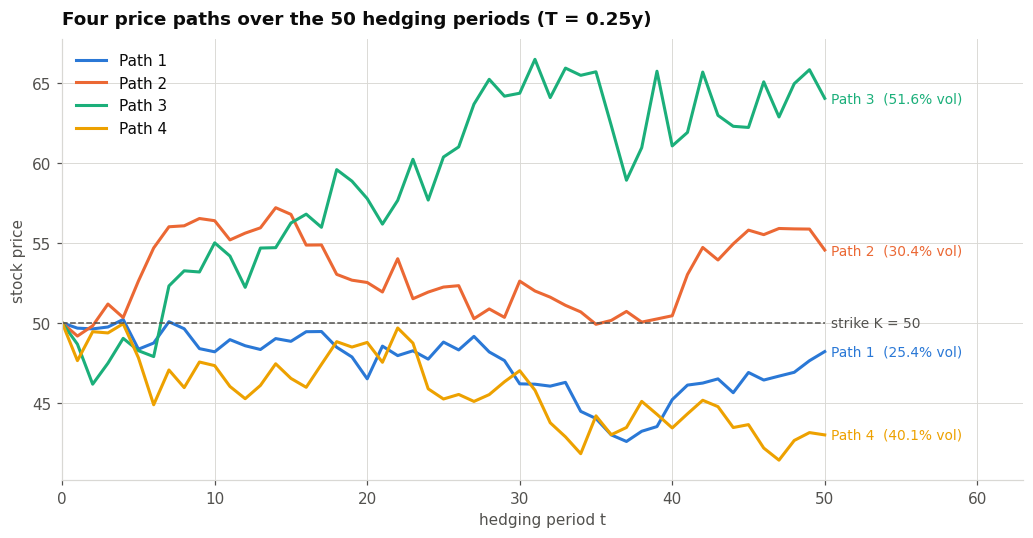

In [16]:
# ---- The four price paths ---------------------------------------------------
fig, ax = plt.subplots()
periods = np.arange(N_PER + 1)
for (name, S), colour in zip(paths.items(), SERIES):
    ax.plot(periods, S, color=colour, label=name)
    ax.annotate(f"{name}  ({res.loc[name, 'realized vol %']:.1f}% vol)",
                xy=(N_PER, S[-1]), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=9, color=colour)
ax.plot([0, N_PER], [K, K], color=INK_2, lw=1.0, ls="--")
ax.annotate(f"strike K = {K:.0f}", xy=(N_PER, K), xytext=(4, 0), textcoords="offset points",
            va="center", fontsize=9, color=INK_2)
ax.set_xlim(0, N_PER + 13)
ax.set_title("Four price paths over the 50 hedging periods (T = 0.25y)", loc="left", pad=10)
ax.set_xlabel("hedging period t")
ax.set_ylabel("stock price")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

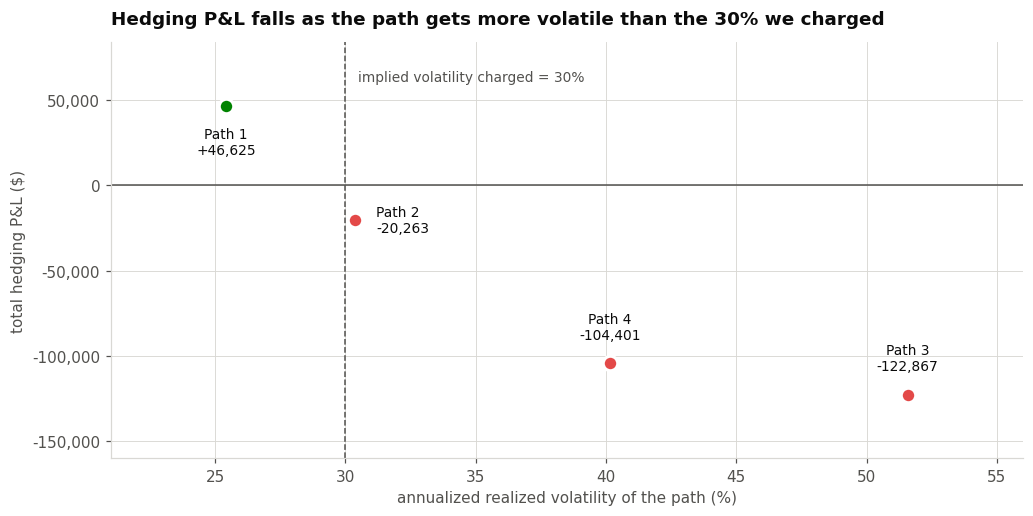

In [17]:
# ---- The punchline: hedging P&L against realized volatility ----------------
fig, ax = plt.subplots(figsize=(9.5, 4.8))

x = res["realized vol %"].to_numpy()
y = res["hedging P&L"].to_numpy()
pad = (y.max() - y.min()) * 0.22
ax.set_xlim(21, 56)
ax.set_ylim(y.min() - pad, y.max() + pad)

ax.axhline(0, color=INK_2, lw=1.0)
ax.axvline(SIGMA * 100, color=INK_2, lw=1.0, ls="--")
ax.annotate("implied volatility charged = 30%", xy=(SIGMA * 100, y.max() + pad * 0.45),
            xytext=(8, 0), textcoords="offset points", va="center", fontsize=9, color=INK_2)

# Labels are placed above each point, except the highest one (which would hit the title)
# and Path 2, which sits on the 30% line and is pushed out to the right instead.
offsets = {"Path 1": (0, -14, "center", "top"), "Path 2": (14, 0, "left", "center"),
           "Path 3": (0, 14, "center", "bottom"), "Path 4": (0, 14, "center", "bottom")}

for xi, yi, name in zip(x, y, res.index):
    colour = GREEN if yi > 0 else RED
    dx, dy, ha, va = offsets[name]
    ax.scatter(xi, yi, s=90, color=colour, zorder=3, edgecolor="white", linewidth=2)
    ax.annotate(f"{name}\n{yi:+,.0f}", xy=(xi, yi), xytext=(dx, dy), textcoords="offset points",
                ha=ha, va=va, fontsize=9, color=INK)

ax.set_title("Hedging P&L falls as the path gets more volatile than the 30% we charged",
             loc="left", pad=12)
ax.set_xlabel("annualized realized volatility of the path (%)")
ax.set_ylabel("total hedging P&L ($)")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
plt.tight_layout()
plt.show()


## 7. Compiling the answers back into Excel

The grader wants Excel work, so the cell below writes
**`EquityDerivsPractice_PSet3_solutions.xlsx`**: a copy of the course workbook — `DemoSheet` and
`StockPricePaths` are carried over untouched — plus the answer sheets. Re-running the cell against
that same file rebuilds the answer sheets in place, so there is only ever one workbook to hand in.
It contains the two original worksheets plus:

| New sheet | What is in it |
|---|---|
| `Answers` | the eight submission answers, each as a **live cross-sheet formula**, plus the parameter block, the realized-vs-implied comparison, and a written explanation of the method |
| `Path1_Hedge` … `Path4_Hedge` | the full 51-row hedging table for each path, built from **live Excel formulas** (`NORMSDIST`, `EXP`, `LN`, `STDEV`) that read the prices straight out of `StockPricePaths` |
| `DemoCheck_Hedge` | the same construction driven off `DemoSheet!E`, so `L19` should reproduce `DemoSheet!B11` = 55,394 — the built-in proof that the formulas are right |

Column formulas on every `*_Hedge` sheet (row 2 is $t=0$, row 52 is $t=50$):

| Col | Meaning | Formula |
|---|---|---|
| `A` | period $t$ | `=A2+1` |
| `B` | $S_t$ | `=StockPricePaths!B2` |
| `C` | $\tau=T-t\Delta t$ | `=$L$3-A2*$L$9` |
| `D` | $d_1$ | `=(LN(B2/$L$6)+($L$5+0.5*$L$4^2)*C2)/($L$4*SQRT(C2))` |
| `E` | $\Delta=N(d_1)$ | `=NORMSDIST(D2)` |
| `F` | shares $x_t$ | `=E2*$L$7` |
| `G` | portfolio $V_t$ | $t=0$: `=$L$7*(B2*NORMSDIST(D2)-$L$6*EXP(-$L$5*C2)*NORMSDIST(D2-$L$4*SQRT(C2)))`, then `=F2*B3+H2*EXP($L$5*$L$9)` |
| `H` | cash $c_t$ | `=G2-F2*B2` |
| `I` | $u_t=\ln(S_t/S_{t-1})$ | `=LN(B3/B2)` |

and the two answers per sheet:

* `L14` = `=ROUND(STDEV(I3:I52)/SQRT($L$9)*100,2)` → the volatility answer,
* `L19` = `=ROUND(G52-MAX(B52-$L$6,0)*$L$7,0)` → the P&L answer.

`NORMSDIST` (rather than `NORM.S.DIST`) is used deliberately: it is the legacy name that opens in every
version of Excel and in LibreOffice.

In [18]:
# ---- Build EquityDerivsPractice_PSet3_solutions.xlsx -----------------------
from openpyxl.styles import Alignment, Font, PatternFill
from openpyxl.utils import get_column_letter

OUT = XLSX.with_name("EquityDerivsPractice_PSet3_solutions.xlsx")

wb_out = openpyxl.load_workbook(XLSX)          # keeps DemoSheet and StockPricePaths as they are
wb_out.calculation.fullCalcOnLoad = True       # force Excel to evaluate our formulas on open

# Re-running the notebook against the solutions workbook itself: drop the generated
# sheets first so they are rebuilt from scratch rather than duplicated.
for stale in ["Answers", *[f"Path{j}_Hedge" for j in range(1, 5)], "DemoCheck_Hedge"]:
    if stale in wb_out.sheetnames:
        del wb_out[stale]

TITLE  = Font(bold=True, size=13)
HEAD   = Font(bold=True, color="FFFFFF")
FILL   = PatternFill("solid", fgColor="2A78D6")
LABEL  = Font(bold=True)
ANSWER = Font(bold=True, color="1B7A3E")
WRAP   = Alignment(wrap_text=True, vertical="top")

HEADERS = ["Period t", "Stock Price S_t", "Time to maturity (T-t)", "d1", "Delta = N(d1)",
           "# Stocks held x_t", "S.F. Portfolio Value V_t", "Cash Account $ c_t",
           "Log-return ln(S_t/S_t-1)"]

COL_NOTES = [
    "A  Period t = 0..50.",
    "B  Stock price, linked to the price path (this is the only input).",
    "C  Time to maturity tau = T - t*dt, dt = T/50 = 0.005 years.",
    "D  d1 = (LN(S/K) + (r + 0.5*sigma^2)*tau) / (sigma*SQRT(tau)), sigma = IMPLIED vol 30%.",
    "E  Delta = N(d1) = NORMSDIST(d1): shares to hold per option.",
    "F  # stocks held x_t = Delta * 100,000 options.",
    "G  Self-financing portfolio. Row 2 = Black-Scholes premium received;",
    "   afterwards V_t+1 = x_t*S_t+1 + c_t*EXP(r*dt)  (no cash added or withdrawn).",
    "H  Cash account c_t = V_t - x_t*S_t (negative: we borrow to buy the hedge).",
    "I  Log-returns used for the realized-volatility answer.",
]


def build_hedge_sheet(wb, title, price_ref, source_label):
    """One 51-row delta-hedging table built entirely from live Excel formulas."""
    ws = wb.create_sheet(title)

    for c, h in enumerate(HEADERS, start=1):
        cell = ws.cell(row=1, column=c, value=h)
        cell.font, cell.fill, cell.alignment = HEAD, FILL, WRAP

    # ---- parameters, linked to DemoSheet so nothing is hard-coded ----
    ws["K1"], ws["L1"] = "Parameter", "Value"
    ws["K1"].font = ws["L1"].font = LABEL
    for i, (lab, ref) in enumerate([
        ("Initial stock price S0", "=DemoSheet!$B$2"), ("Expiration T (years)", "=DemoSheet!$B$3"),
        ("Implied volatility", "=DemoSheet!$B$4"), ("Risk-free rate r", "=DemoSheet!$B$5"),
        ("Strike K", "=DemoSheet!$B$6"), ("# of options sold", "=DemoSheet!$B$7"),
        ("# of hedging periods", "=DemoSheet!$B$8"),
    ], start=2):
        ws.cell(row=i, column=11, value=lab)
        ws.cell(row=i, column=12, value=ref)
    ws["K9"], ws["L9"] = "dt = T / # periods", "=L3/L8"

    # ---- the hedging table ----
    for i in range(N_PER + 1):          # i = period t, row = i + 2
        row = i + 2
        ws.cell(row=row, column=1, value=0 if i == 0 else f"=A{row - 1}+1")
        ws.cell(row=row, column=2, value=price_ref(i)).number_format = "#,##0.000000"
        ws.cell(row=row, column=3, value=f"=$L$3-A{row}*$L$9").number_format = "0.0000"

        if i < N_PER:                   # no rebalancing at expiration
            ws.cell(row=row, column=4,
                    value=f"=(LN(B{row}/$L$6)+($L$5+0.5*$L$4^2)*C{row})/($L$4*SQRT(C{row}))"
                    ).number_format = "0.000000"
            ws.cell(row=row, column=5, value=f"=NORMSDIST(D{row})").number_format = "0.000000"
            ws.cell(row=row, column=6, value=f"=E{row}*$L$7").number_format = "#,##0.00"

        if i == 0:                      # premium received for the 100,000 calls
            ws.cell(row=row, column=7,
                    value="=$L$7*(B2*NORMSDIST(D2)-$L$6*EXP(-$L$5*C2)*NORMSDIST(D2-$L$4*SQRT(C2)))")
        else:                           # the self-financing recursion
            ws.cell(row=row, column=7, value=f"=F{row - 1}*B{row}+H{row - 1}*EXP($L$5*$L$9)")
        ws.cell(row=row, column=7).number_format = "#,##0.00"

        if i < N_PER:
            ws.cell(row=row, column=8, value=f"=G{row}-F{row}*B{row}").number_format = "#,##0.00"
        if i > 0:
            ws.cell(row=row, column=9, value=f"=LN(B{row}/B{row - 1})").number_format = "0.000000"

    last = N_PER + 2                    # row 52 = period 50
    block = [
        ("RESULTS", None, None),
        ("Mean log-return (annualized)", f"=AVERAGE(I3:I{last})/$L$9", "0.0000"),
        ("Realized volatility (annualized)", f"=STDEV(I3:I{last})/SQRT($L$9)", "0.000000"),
        ("ANSWER - realized vol in %, 2 dp", f"=ROUND(L13*100,2)", "0.00"),
        ("Terminal stock price S_T", f"=B{last}", "#,##0.000000"),
        ("Option payoff = # options x MAX(S_T-K,0)", "=MAX(L15-$L$6,0)*$L$7", "#,##0.00"),
        ("Final self-financing portfolio V_T", f"=G{last}", "#,##0.00"),
        ("Total hedging P&L = V_T - payoff", "=L17-L16", "#,##0.00"),
        ("ANSWER - P&L to nearest integer", "=ROUND(L18,0)", "#,##0"),
    ]
    for i, (lab, formula, fmt) in enumerate(block, start=11):
        ws.cell(row=i, column=11, value=lab).font = LABEL if formula is None else Font()
        if formula:
            c = ws.cell(row=i, column=12, value=formula)
            c.number_format = fmt
            if lab.startswith("ANSWER"):
                c.font = ANSWER
    ws["K11"].font = TITLE

    ws["K21"] = f"Prices are linked to {source_label}. Every other column is a live formula:"
    ws["K21"].font = LABEL
    for i, note in enumerate(COL_NOTES, start=22):
        ws.cell(row=i, column=11, value=note)

    widths = {"A": 9, "B": 16, "C": 20, "D": 11, "E": 13, "F": 17, "G": 24, "H": 20, "I": 22,
              "K": 42, "L": 18}
    for col, w in widths.items():
        ws.column_dimensions[col].width = w
    ws.freeze_panes = "B2"
    return ws


for j, name in enumerate(paths, start=1):
    col = get_column_letter(1 + j)                       # StockPricePaths columns B..E
    build_hedge_sheet(wb_out, f"Path{j}_Hedge",
                      lambda i, col=col: f"=StockPricePaths!{col}{2 + i}",
                      f"StockPricePaths!{col}")

build_hedge_sheet(wb_out, "DemoCheck_Hedge",
                  lambda i: f"=DemoSheet!E{2 + i}", "DemoSheet!E (the worked example)")

print("hedge sheets built:", [ws.title for ws in wb_out.worksheets])

hedge sheets built: ['DemoSheet', 'StockPricePaths', 'Path1_Hedge', 'Path2_Hedge', 'Path3_Hedge', 'Path4_Hedge', 'DemoCheck_Hedge']


In [19]:
# ---- The Answers sheet: live formulas, values, and the write-up ------------
ans = wb_out.create_sheet("Answers", 0)          # first tab in the workbook

ans["A1"] = "Practice Set 3 - Delta-hedging P&L and realized volatility: worked answers"
ans["A1"].font = TITLE

intro = [
    "SETUP.  At t=0 we sell 100,000 European calls (K=50, T=0.25y) for the Black-Scholes premium computed with a 30% IMPLIED volatility,",
    "and we delta-hedge them with a self-financing portfolio rebalanced 50 times.  Holding x_t = N(d1)*100,000 shares and c_t = V_t - x_t*S_t in cash,",
    "the portfolio rolls forward as   V_t+1 = x_t*S_t+1 + c_t*EXP(r*dt),   dt = T/50 = 0.005 years.   No money is ever added or taken out.",
    "",
    "ANSWER 1 (volatility).  u_t = LN(S_t / S_t-1) for t = 1..50.   Annualized realized vol = STDEV(u_1..u_50) / SQRT(dt) = STDEV(...) * SQRT(200).",
    "                        STDEV (sample, n-1) is the right convention: it reproduces DemoSheet!N2 exactly; STDEVP does not.",
    "ANSWER 2 (P&L).         Total hedging P&L = V_50 - 100,000 * MAX(S_50 - K, 0)   =   final portfolio value minus the option payoff (DemoSheet!B11).",
    "",
    "Each answer below is a LIVE formula pointing at the sheet PathN_Hedge, where the whole 51-row table is itself built from live Excel formulas.",
    "DemoCheck_Hedge applies the identical construction to the worked example: its L19 reproduces DemoSheet!B11 = 55,394, which validates the method.",
]
for i, line in enumerate(intro, start=3):
    ans.cell(row=i, column=1, value=line)

r0 = 3 + len(intro) + 1
for c, h in enumerate(["Q", "Path", "Quantity", "Excel answer (live formula)",
                       "Python answer", "SUBMIT"], start=1):
    cell = ans.cell(row=r0, column=c, value=h)
    cell.font, cell.fill = HEAD, FILL

rows = []
for j, name in enumerate(paths, start=1):
    rows.append((2 * j - 1, f"#{j}", "Annualized realized volatility of log-returns (%)",
                 f"=Path{j}_Hedge!$L$14", res.loc[name, "ANSWER vol (2 dp)"], "0.00"))
    rows.append((2 * j, f"#{j}", "Total realized P&L when delta-hedging ($)",
                 f"=Path{j}_Hedge!$L$19", int(res.loc[name, "ANSWER P&L (integer)"]), "#,##0"))

for i, (q, path, quantity, formula, value, fmt) in enumerate(rows, start=r0 + 1):
    ans.cell(row=i, column=1, value=q)
    ans.cell(row=i, column=2, value=path)
    ans.cell(row=i, column=3, value=quantity)
    ans.cell(row=i, column=4, value=formula).number_format = fmt
    ans.cell(row=i, column=5, value=value).number_format = fmt
    c = ans.cell(row=i, column=6, value=value)
    c.number_format, c.font = fmt, ANSWER

r1 = r0 + len(rows) + 2
ans.cell(row=r1, column=1, value="REALIZED vs IMPLIED VOLATILITY").font = TITLE
for c, h in enumerate(["Path", "Realized vol", "Implied vol", "Gap (real - implied)",
                       "S_T", "Option payoff", "Final portfolio V_T", "Hedging P&L", "Verdict"], start=1):
    cell = ans.cell(row=r1 + 1, column=c, value=h)
    cell.font, cell.fill = HEAD, FILL

for i, (name, row) in enumerate(res.iterrows(), start=r1 + 2):
    j = int(name.split()[-1])
    ans.cell(row=i, column=1, value=name)
    ans.cell(row=i, column=2, value=f"=Path{j}_Hedge!$L$13").number_format = "0.00%"
    ans.cell(row=i, column=3, value="=DemoSheet!$B$4").number_format = "0.00%"
    ans.cell(row=i, column=4, value=f"=B{i}-C{i}").number_format = "+0.00%;-0.00%"
    ans.cell(row=i, column=5, value=f"=Path{j}_Hedge!$L$15").number_format = "#,##0.0000"
    ans.cell(row=i, column=6, value=f"=Path{j}_Hedge!$L$16").number_format = "#,##0"
    ans.cell(row=i, column=7, value=f"=Path{j}_Hedge!$L$17").number_format = "#,##0"
    ans.cell(row=i, column=8, value=f"=Path{j}_Hedge!$L$18").number_format = "#,##0"
    ans.cell(row=i, column=9, value=f'=IF(B{i}<C{i},"calmer than implied -> hedging PROFIT",'
                                    f'"wilder than implied -> hedging LOSS")')

r2 = r1 + 2 + len(res) + 1
conclusion = [
    "VALIDATION:  DemoCheck_Hedge!L19 must equal DemoSheet!B11 (= 55,394).  Live check ->",
    "",
    "CONCLUSION.  Selling and delta-hedging an option is a bet on volatility, not on direction:",
    "  * Path #1 realizes 25.42%, BELOW the 30% we charged: the stock moved less than we were paid for, so the hedge profits (+46,625).",
    "  * Path #2 realizes 30.36%, essentially AT implied: theory says P&L ~ 0; the -20,263 left over is discrete-hedging error (we rebalance 50 times, not continuously).",
    "  * Path #3 realizes 51.57% and Path #4 realizes 40.14%, well ABOVE implied: both lose heavily (-122,867 and -104,401).",
    "  * Direction is irrelevant.  Path #3 finishes deep in the money and Path #4 finishes worthless, yet BOTH lose money, because both were far more volatile than 30%.",
    "    Path #4's loss is burned in the whipsawing hedge (buying high, selling low), even though the option it hedged expired worthless.",
    "  * Rule of thumb:  P&L ~ 0.5 * INTEGRAL[ exp(r(T-t)) * S_t^2 * Gamma_t * (sigma_implied^2 - sigma_realized^2) ] dt   -> positive only when implied > realized.",
]
for i, line in enumerate(conclusion, start=r2):
    ans.cell(row=i, column=1, value=line)
ans.cell(row=r2, column=4, value="=DemoCheck_Hedge!$L$19").number_format = "#,##0"
ans.cell(row=r2, column=5, value="=DemoSheet!$B$11").number_format = "#,##0"
ans.cell(row=r2, column=6, value=f'=IF(ROUND(D{r2}-E{r2},0)=0,"MATCH","CHECK")').font = ANSWER

for col, w in [("A", 46), ("B", 14), ("C", 52), ("D", 26), ("E", 16), ("F", 16),
               ("G", 20), ("H", 16), ("I", 40)]:
    ans.column_dimensions[col].width = w

wb_out.save(OUT)
print(f"written: {OUT}")
print("sheets :", wb_out.sheetnames)

written: /Users/pathorn.kit/financial-student-lecture/notebook/test/Equity_Derivatives _Practice_Part_I/EquityDerivsPractice_PSet3_solutions.xlsx
sheets : ['Answers', 'DemoSheet', 'StockPricePaths', 'Path1_Hedge', 'Path2_Hedge', 'Path3_Hedge', 'Path4_Hedge', 'DemoCheck_Hedge']


In [20]:
# ---- Re-read the saved workbook and confirm what is in it ------------------
chk = openpyxl.load_workbook(OUT)          # formulas, not cached values
a = chk["Answers"]
p1 = chk["Path1_Hedge"]

print("Answers!A1        :", a["A1"].value)
print("Path1_Hedge!D2    :", p1["D2"].value)
print("Path1_Hedge!G2    :", p1["G2"].value)
print("Path1_Hedge!G3    :", p1["G3"].value)
print("Path1_Hedge!L13   :", p1["L13"].value)
print("Path1_Hedge!L19   :", p1["L19"].value)
print("\nSheets:", chk.sheetnames)
print("\nNote: openpyxl stores formulas without cached results, so Excel/LibreOffice computes")
print("them on open (fullCalcOnLoad is set). The 'Python answer' column holds the same numbers")
print("as static values, so the answers are readable even without opening Excel.")

Answers!A1        : Practice Set 3 - Delta-hedging P&L and realized volatility: worked answers
Path1_Hedge!D2    : =(LN(B2/$L$6)+($L$5+0.5*$L$4^2)*C2)/($L$4*SQRT(C2))
Path1_Hedge!G2    : =$L$7*(B2*NORMSDIST(D2)-$L$6*EXP(-$L$5*C2)*NORMSDIST(D2-$L$4*SQRT(C2)))
Path1_Hedge!G3    : =F2*B3+H2*EXP($L$5*$L$9)
Path1_Hedge!L13   : =STDEV(I3:I52)/SQRT($L$9)
Path1_Hedge!L19   : =ROUND(L18,0)

Sheets: ['Answers', 'DemoSheet', 'StockPricePaths', 'Path1_Hedge', 'Path2_Hedge', 'Path3_Hedge', 'Path4_Hedge', 'DemoCheck_Hedge']

Note: openpyxl stores formulas without cached results, so Excel/LibreOffice computes
them on open (fullCalcOnLoad is set). The 'Python answer' column holds the same numbers
as static values, so the answers are readable even without opening Excel.


## 8. Final answers

| Q | Path | Quantity | **Submit** |
|---|---|---|---|
| 1 | #1 | annualized realized volatility | **25.42** |
| 2 | #1 | total realized hedging P&L | **46625** |
| 3 | #2 | annualized realized volatility | **30.36** |
| 4 | #2 | total realized hedging P&L | **-20263** |
| 5 | #3 | annualized realized volatility | **51.57** |
| 6 | #3 | total realized hedging P&L | **-122867** |
| 7 | #4 | annualized realized volatility | **40.14** |
| 8 | #4 | total realized hedging P&L | **-104401** |

**Method, in one paragraph.** Every path is hedged with the same contract terms — 100,000 calls,
$K=50$, $T=0.25$, $r=2\%$, and a **30% implied volatility** that is fixed at inception. The premium
$V_0=310{,}815.12$ is invested in $N(d_1)\times100{,}000$ shares plus a (negative) cash balance, and the
portfolio is rolled forward 50 times with $V_{t+1}=x_tS_{t+1}+c_te^{r\Delta t}$. The answer to the
volatility questions is $\operatorname{STDEV}(u_1..u_{50})\times\sqrt{200}$ with
$u_t=\ln(S_t/S_{t-1})$; the answer to the P&L questions is $V_{50}$ minus the option payoff. The method
reproduces `DemoSheet!B11` $=55{,}393.58$ to nine decimal places, which is the built-in check the
exercise provides.

**Takeaway.** A delta-hedged short option position is a **short volatility** position. Paths that
realize *less* volatility than the 30% charged produce a hedging profit; paths that realize *more*
produce a loss, regardless of whether the option ends up in or out of the money.